In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# change the directory below to be able to read the data at your end 
dft = pd.read_csv(r"data\application_train.csv")

In [3]:
# general info about dataset
display(dft.shape, dft.info(), dft.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


(307511, 122)

None

0

In [4]:
list(dft.columns)

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

### Exploratory Data Analysis

#### Identify missing values, outliers, and class distribution.

In [5]:
dfta = dft[['SK_ID_CURR','TARGET','CODE_GENDER','FLAG_OWN_CAR','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',\
            'NAME_INCOME_TYPE','NAME_EDUCATION_TYPE',\
            'FLAG_PHONE','CNT_FAM_MEMBERS','REG_CITY_NOT_LIVE_CITY',\
            'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT']]
dfta.sample(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,FLAG_PHONE,CNT_FAM_MEMBERS,REG_CITY_NOT_LIVE_CITY,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT
152225,276436,1,F,N,38700.0,417024.0,22752.0,Pensioner,Secondary / secondary special,0,2.0,0,NaN,NaN
233742,370744,0,F,Y,135000.0,450000.0,22500.0,Working,Higher education,0,4.0,0,0.0,0.0
129066,249708,0,F,N,180000.0,248760.0,24363.0,Working,Secondary / secondary special,1,1.0,0,1.0,0.0
21391,124922,0,F,N,157500.0,188685.0,17433.0,Commercial associate,Higher education,0,2.0,1,0.0,0.0
124854,244795,0,M,N,99000.0,119893.5,12415.5,Commercial associate,Secondary / secondary special,0,3.0,0,NaN,NaN


In [6]:
# check for missing values
dfta.isna().sum()

SK_ID_CURR                       0
TARGET                           0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
AMT_INCOME_TOTAL                 0
AMT_CREDIT                       0
AMT_ANNUITY                     12
NAME_INCOME_TYPE                 0
NAME_EDUCATION_TYPE              0
FLAG_PHONE                       0
CNT_FAM_MEMBERS                  2
REG_CITY_NOT_LIVE_CITY           0
AMT_REQ_CREDIT_BUREAU_MON    41519
AMT_REQ_CREDIT_BUREAU_QRT    41519
dtype: int64

In [7]:
dfta["AMT_REQ_CREDIT_BUREAU_MON"] = dfta["AMT_REQ_CREDIT_BUREAU_MON"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_MON"].median())
dfta["AMT_REQ_CREDIT_BUREAU_QRT"] = dfta["AMT_REQ_CREDIT_BUREAU_QRT"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_QRT"].median())

C:\Users\Dell\AppData\Local\Temp\ipykernel_13888\2316345651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfta["AMT_REQ_CREDIT_BUREAU_MON"] = dfta["AMT_REQ_CREDIT_BUREAU_MON"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_MON"].median())
C:\Users\Dell\AppData\Local\Temp\ipykernel_13888\2316345651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfta["AMT_REQ_CREDIT_BUREAU_QRT"] = dfta["AMT_REQ_CREDIT_BUREAU_QRT"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_QRT"].median())


In [8]:
# summary of missing values and general information
display(dfta.isna().sum(), dfta.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SK_ID_CURR                 307511 non-null  int64  
 1   TARGET                     307511 non-null  int64  
 2   CODE_GENDER                307511 non-null  object 
 3   FLAG_OWN_CAR               307511 non-null  object 
 4   AMT_INCOME_TOTAL           307511 non-null  float64
 5   AMT_CREDIT                 307511 non-null  float64
 6   AMT_ANNUITY                307499 non-null  float64
 7   NAME_INCOME_TYPE           307511 non-null  object 
 8   NAME_EDUCATION_TYPE        307511 non-null  object 
 9   FLAG_PHONE                 307511 non-null  int64  
 10  CNT_FAM_MEMBERS            307509 non-null  float64
 11  REG_CITY_NOT_LIVE_CITY     307511 non-null  int64  
 12  AMT_REQ_CREDIT_BUREAU_MON  307511 non-null  float64
 13  AMT_REQ_CREDIT_BUREAU_QRT  30

SK_ID_CURR                    0
TARGET                        0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                  12
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
FLAG_PHONE                    0
CNT_FAM_MEMBERS               2
REG_CITY_NOT_LIVE_CITY        0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
dtype: int64

None

In [9]:
# statistical description for categorical features 
dfta.describe(exclude='number')

,CODE_GENDER,FLAG_OWN_CAR,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE
count,307511,307511,307511,307511
unique,3,2,8,5
top,F,N,Working,Secondary / secondary special
freq,202448,202924,158774,218391


In [10]:
# descriptive statistics for numerical features
dfta.describe(exclude='object') 

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,FLAG_PHONE,CNT_FAM_MEMBERS,REG_CITY_NOT_LIVE_CITY,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,1.687979e+05,5.990260e+05,27108.573909,0.281066,2.152665,0.078173,0.231293,0.229631
std,102790.175348,0.272419,2.371231e+05,4.024908e+05,14493.737315,0.449521,0.910682,0.268444,0.856810,0.744059
min,100002.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,1.125000e+05,2.700000e+05,16524.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,0.000000,2.000000,0.000000,0.000000,0.000000
75%,367142.500000,0.000000,2.025000e+05,8.086500e+05,34596.000000,1.000000,3.000000,0.000000,0.000000,0.000000
max,456255.000000,1.000000,1.170000e+08,4.050000e+06,258025.500000,1.000000,20.000000,1.000000,27.000000,261.000000


In [11]:
# outlier detection for:
# Detect Outlier - AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY
def detect_outliers_iqr(df, columns, return_all_outliers=True, flag_outliers=False):
    df_out = df.copy()
    outlier_indices = set()
    outlier_dict = {}

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Boolean mask for outliers
        mask = (df[column] < lower_bound) | (df[column] > upper_bound)
        # Store outlier indices for this column
        outlier_dict[column] = df[mask]
        if flag_outliers:
            flag_col_name = f'{column}_outlier_flag'
            df_out[flag_col_name] = mask.astype(int)

        if return_all_outliers:
            outlier_indices.update(df[mask].index)
    if return_all_outliers:
        return df_out.loc[list(outlier_indices)]
    elif flag_outliers:
        return df_out
    else:
        return outlier_dict

In [12]:
# detection of outliers
outliers_per_column = detect_outliers_iqr(dfta, ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"], return_all_outliers=False)
print("\nOutliers per column:")
for col, outliers in outliers_per_column.items():
    print(f"\n{col}:\n{outliers}")


Outliers per column:

AMT_INCOME_TOTAL:
        SK_ID_CURR  TARGET CODE_GENDER FLAG_OWN_CAR  AMT_INCOME_TOTAL  \
7           100010       0           M            Y          360000.0   
22          100026       0           F            N          450000.0   
33          100039       0           M            Y          360000.0   
49          100056       0           M            Y          360000.0   
51          100059       0           M            Y          540000.0   
...            ...     ...         ...          ...               ...   
307460      456199       0           M            Y          382500.0   
307477      456217       0           F            N          360000.0   
307484      456228       0           F            Y          540000.0   
307492      456236       0           M            Y          585000.0   
307496      456240       0           F            N          360000.0   

        AMT_CREDIT  AMT_ANNUITY      NAME_INCOME_TYPE  \
7        1530000.0      4

In [13]:
# Handle outliers
def replace_outliers_with_median(df, columns):
    df_out = df.copy()
    for column in columns:
        Q1 = df_out[column].quantile(0.25)
        Q3 = df_out[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median = df_out[column].median()

        # Replace outliers with median
        df_out[column] = df_out[column].apply(
            lambda x: median if (x < lower_bound or x > upper_bound) else x
        )
    return df_out

In [14]:
# Replace outliers with median
df_clean = replace_outliers_with_median(dfta, ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"])

In [15]:
# check for duplicate entry
df_clean.duplicated().sum()

0

In [16]:
# drop duplicate entry
df_clean.drop_duplicates(inplace=True)

In [17]:
# class distribution
df_clean['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

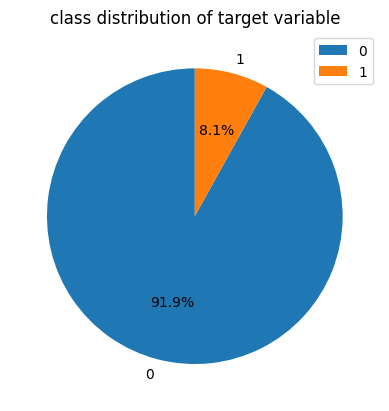

In [18]:
# 
counts = df_clean['TARGET'].value_counts()
labels = counts.index
sizes = counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("class distribution of target variable")
plt.legend()
plt.show()

#### Summarize dataset structure and key statistics.

In [19]:
# correct the datatype
df_clean["TARGET"] = df_clean["TARGET"].astype('str')
df_clean["REG_CITY_NOT_LIVE_CITY"] = df_clean["REG_CITY_NOT_LIVE_CITY"].astype('boolean')
df_clean["FLAG_OWN_CAR"] = df_clean["FLAG_OWN_CAR"].astype('str')
df_clean["FLAG_PHONE"] = df_clean["FLAG_PHONE"].astype('boolean')

In [20]:
# dataset summary
df_clean.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SK_ID_CURR                 307511 non-null  int64  
 1   TARGET                     307511 non-null  object 
 2   CODE_GENDER                307511 non-null  object 
 3   FLAG_OWN_CAR               307511 non-null  object 
 4   AMT_INCOME_TOTAL           307511 non-null  float64
 5   AMT_CREDIT                 307511 non-null  float64
 6   AMT_ANNUITY                307499 non-null  float64
 7   NAME_INCOME_TYPE           307511 non-null  object 
 8   NAME_EDUCATION_TYPE        307511 non-null  object 
 9   FLAG_PHONE                 307511 non-null  boolean
 10  CNT_FAM_MEMBERS            307509 non-null  float64
 11  REG_CITY_NOT_LIVE_CITY     307511 non-null  boolean
 12  AMT_REQ_CREDIT_BUREAU_MON  307511 non-null  float64
 13  AMT_REQ_CREDIT_BUREAU_QRT  30

In [21]:
# summary of categorical variables
df_clean.describe(exclude='number')

,TARGET,CODE_GENDER,FLAG_OWN_CAR,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,FLAG_PHONE,REG_CITY_NOT_LIVE_CITY
count,307511,307511,307511,307511,307511,307511,307511
unique,2,3,2,8,5,2,2
top,0,F,N,Working,Secondary / secondary special,False,False
freq,282686,202448,202924,158774,218391,221080,283472


In [22]:
# summary of numerical variables
df_clean.describe(exclude='category')

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,FLAG_PHONE,CNT_FAM_MEMBERS,REG_CITY_NOT_LIVE_CITY,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT
count,307511.000000,307511,307511,307511,307511.000000,3.075110e+05,307499.000000,307511,307511,307511,307509.000000,307511,307511.000000,307511.000000
unique,NaN,2,3,2,NaN,NaN,NaN,8,5,2,NaN,2,NaN,NaN
top,NaN,0,F,N,NaN,NaN,NaN,Working,Secondary / secondary special,False,NaN,False,NaN,NaN
freq,NaN,282686,202448,202924,NaN,NaN,NaN,158774,218391,221080,NaN,283472,NaN,NaN
mean,278180.518577,NaN,NaN,NaN,153939.251340,5.687740e+05,25899.664090,NaN,NaN,NaN,2.152665,NaN,0.231293,0.229631
std,102790.175348,NaN,NaN,NaN,62554.665158,3.490408e+05,12080.815217,NaN,NaN,NaN,0.910682,NaN,0.856810,0.744059
min,100002.000000,NaN,NaN,NaN,25650.000000,4.500000e+04,1615.500000,NaN,NaN,NaN,1.000000,NaN,0.000000,0.000000
25%,189145.500000,NaN,NaN,NaN,112500.000000,2.700000e+05,16524.000000,NaN,NaN,NaN,2.000000,NaN,0.000000,0.000000
50%,278202.000000,NaN,NaN,NaN,147150.000000,5.135310e+05,24903.000000,NaN,NaN,NaN,2.000000,NaN,0.000000,0.000000
75%,367142.500000,NaN,NaN,NaN,189000.000000,7.819200e+05,33075.000000,NaN,NaN,NaN,3.000000,NaN,0.000000,0.000000


#### Plot correlations and key relationships.

In [23]:
# gender distribution
df_clean["CODE_GENDER"].value_counts() 

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [24]:
# drop unknown gender
df_clean = df_clean[df_clean["CODE_GENDER"] != "XNA"]

In [25]:
# gender distribution
df_clean["FLAG_OWN_CAR"].value_counts()

FLAG_OWN_CAR
N    202922
Y    104585
Name: count, dtype: int64

In [26]:
# distribution of type of income
df_clean["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158771
Commercial associate     71616
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [27]:
# merge categories with few sample into other categories
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace("Maternity leave","Working")
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace("Businessman","Commercial associate")
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace("Unemployed","Pensioner")
# exclude student because we can't merge them into other groups and are two few to stand alone
df_clean = df_clean[df_clean["NAME_INCOME_TYPE"] != "Student"] 

In [28]:
# distribution of type of education
df_clean["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218378
Higher education                  74856
Incomplete higher                 10275
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [29]:
# merge 'academic degree' into 'higher education'
df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace("Academic degree", "Higher education")
df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace("Secondary / secondary special", "secondary special")

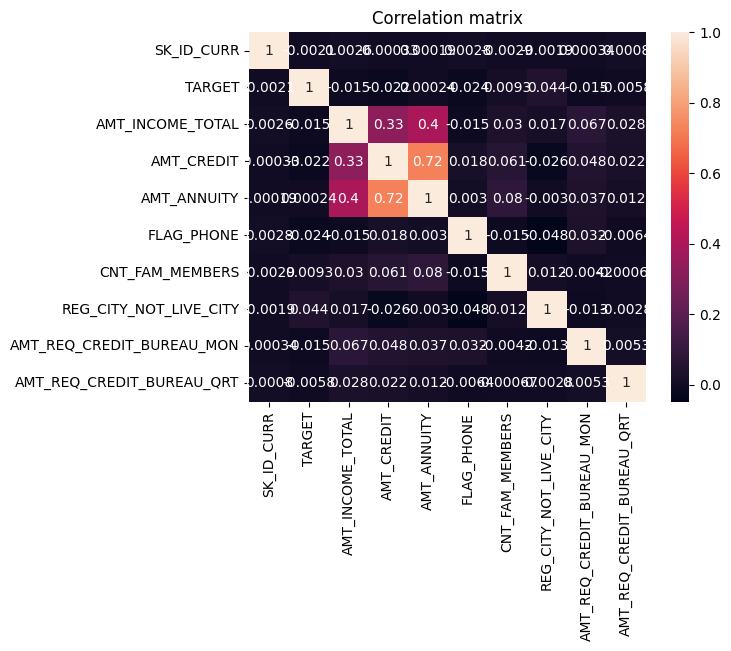

In [30]:
# compute correlation matrix
df_corr = df_clean.drop(['NAME_EDUCATION_TYPE', 'FLAG_OWN_CAR', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'], axis=1)
corr_matrix = df_corr.corr()

# visualize correction matrix as a heatmap
#plt.figure(figure=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation matrix")
plt.show()

##### Level of education based analysis of annuity, credit, and total income

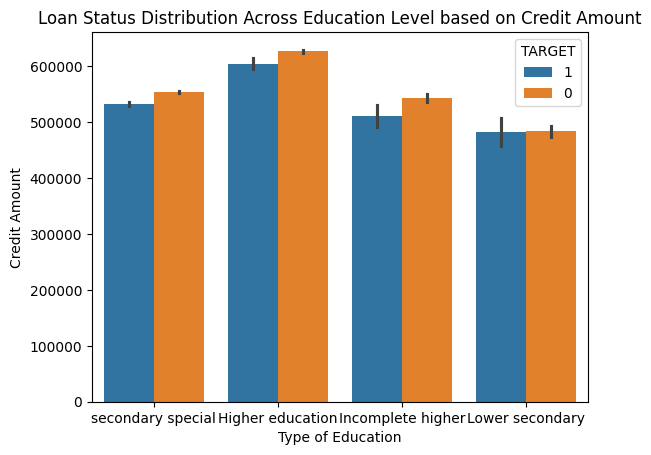

In [31]:
# 'NAME_EDUCATION_TYPE',
sns.barplot(x="NAME_EDUCATION_TYPE", y="AMT_CREDIT", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Education Level based on Credit Amount")
plt.xlabel("Type of Education")
plt.ylabel("Credit Amount")
plt.show()

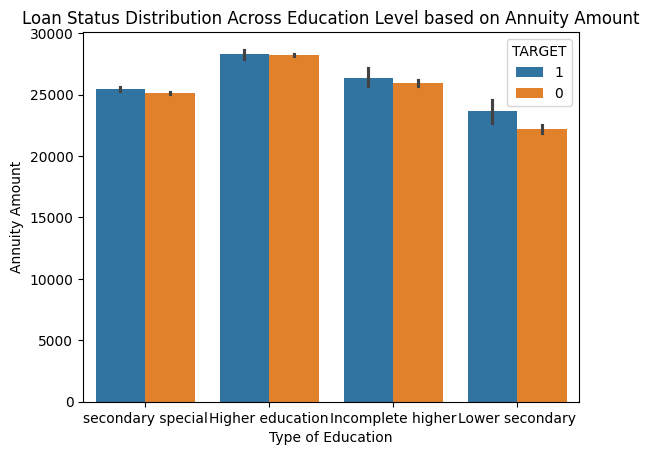

In [32]:
# 'NAME_EDUCATION_TYPE', 
sns.barplot(x="NAME_EDUCATION_TYPE", y="AMT_ANNUITY", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Education Level based on Annuity Amount")
plt.xlabel("Type of Education")
plt.ylabel("Annuity Amount")
plt.show()

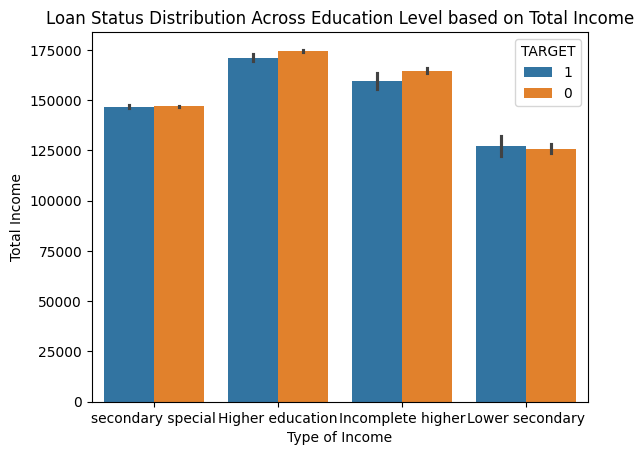

In [33]:
# 'NAME_EDUCATION_TYPE', 
sns.barplot(x="NAME_EDUCATION_TYPE", y="AMT_INCOME_TOTAL", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Education Level based on Total Income")
plt.xlabel("Type of Income")
plt.ylabel("Total Income")
plt.show()

##### Gender based analysis of annuity, credit, and total income

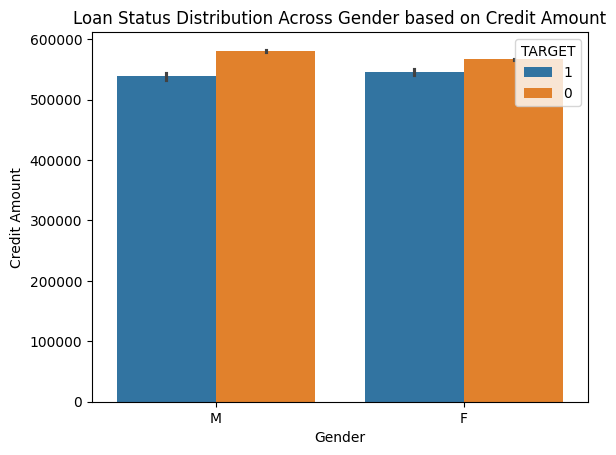

In [34]:
# 
sns.barplot(x="CODE_GENDER", y="AMT_CREDIT", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Gender based on Credit Amount")
plt.xlabel("Gender")
plt.ylabel("Credit Amount")
plt.show()

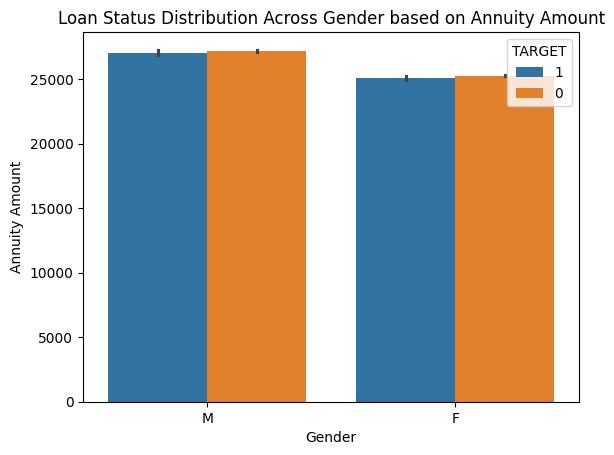

In [35]:
# 'CODE_GENDER',
sns.barplot(x="CODE_GENDER", y="AMT_ANNUITY", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Gender based on Annuity Amount")
plt.xlabel("Gender")
plt.ylabel("Annuity Amount")
plt.show()

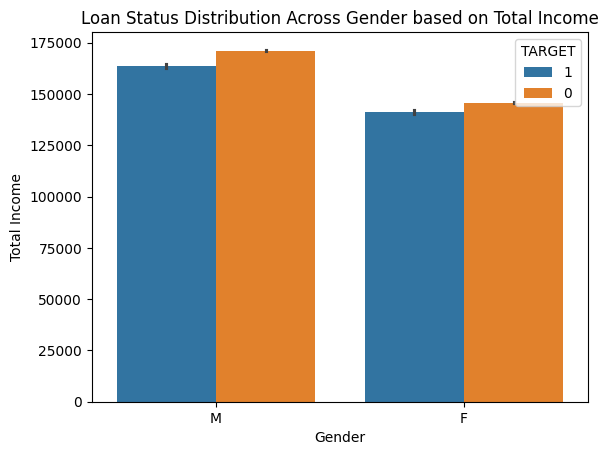

In [36]:
# 'NAME_EDUCATION_TYPE', 'FLAG_OWN_CAR', 'CODE_GENDER', 'NAME_INCOME_TYPE'
sns.barplot(x="CODE_GENDER", y="AMT_INCOME_TOTAL", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Gender based on Total Income")
plt.xlabel("Gender")
plt.ylabel("Total Income")
plt.show()

##### Type of Income based analysis of annuity, credit, and total income

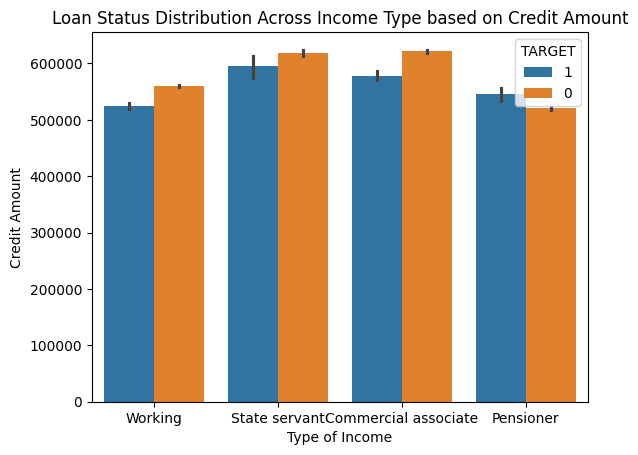

In [37]:
# 'NAME_INCOME_TYPE
sns.barplot(x="NAME_INCOME_TYPE", y="AMT_CREDIT", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Income Type based on Credit Amount")
plt.xlabel("Type of Income")
plt.ylabel("Credit Amount")
plt.show()

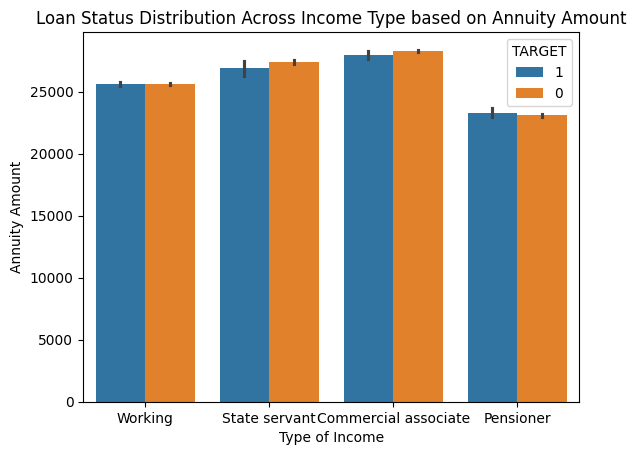

In [38]:
# 'NAME_INCOME_TYPE', 
sns.barplot(x="NAME_INCOME_TYPE", y="AMT_ANNUITY", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Income Type based on Annuity Amount")
plt.xlabel("Type of Income")
plt.ylabel("Annuity Amount")
plt.show()

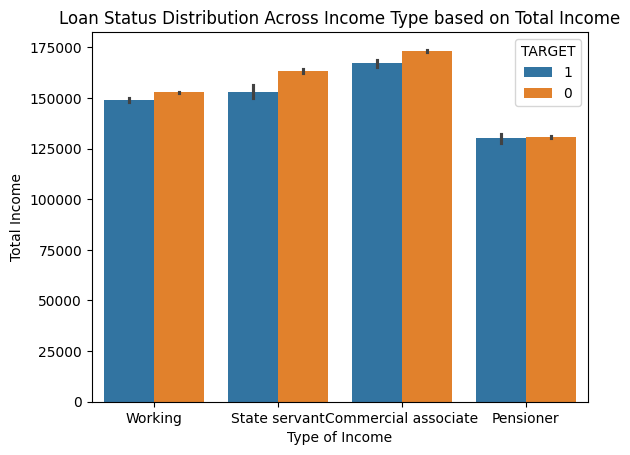

In [39]:
# 'NAME_EDUCATION_TYPE', 'FLAG_OWN_CAR', 'CODE_GENDER', 'NAME_INCOME_TYPE'
sns.barplot(x="NAME_INCOME_TYPE", y="AMT_INCOME_TOTAL", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Income Type based on Total Income")
plt.xlabel("Type of Income")
plt.ylabel("Total Income")
plt.show()

### Insights from EDA
#### Descriptive Statistics
##### 1) Over 90% of the loan data entry did not default.
##### 2) The female gender took the over 66%(2/3rd) of the loans.
##### 3) Majority of those that took the loan are working class.
#### Exploratory Statistics
##### 4) With respect to gender, both the male and female had annuity of around 25000.
##### 5) The 'working class' with 'special higher education' possess the highest credit with over 600,000units irrespective of loan status.
##### 6) Clients with special higher education has income around 175,000units irrespective of loan status.
##### 7) Both the male and female gender has an estimated 550,000units in credit; with annuity of 25,000units. While the men had an estimated total income of around 160,000units; the females receive an estimated 140,000 units.
##### 8) The 'state servants' and 'commercial associates' took the most credit at 600,000units; while maintaining a steady annuity of a little over 25,000 for the same categories of workers. Compared to other workers, the 'state servants' and 'commercial associates' maintain the lead in terms of the highest total income of around 160,000units.

### Feature Engineering

#### Impute missing values effectively.

In [40]:
# check for missing values
df_clean.isna().sum()

SK_ID_CURR                    0
TARGET                        0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                  12
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
FLAG_PHONE                    0
CNT_FAM_MEMBERS               2
REG_CITY_NOT_LIVE_CITY        0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
dtype: int64

In [41]:
# drop missing values because they are less than 5% of the total sample in that specific row
df_clean.dropna(inplace=True)

#### Create relevant features (e.g., Debt-to-Income, payment ratios).

In [42]:
# compute payment ratio ratio
df_clean["PAYMENT_RATIO"] = round(df_clean["AMT_INCOME_TOTAL"] / df_clean["AMT_CREDIT"], 2)

#### Encode categorical variables.

In [43]:
# Encode the following columns:
# 'CODE_GENDER'
cg_dict = list(df_clean['CODE_GENDER'].unique())
cg_result = {i:v for i,v in enumerate(cg_dict)}
cg_result = {v:i for i,v in cg_result.items()}
df_clean["CODE_GENDER"] = df_clean["CODE_GENDER"].replace(cg_result)
cg_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_13888\2913451584.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["CODE_GENDER"] = df_clean["CODE_GENDER"].replace(cg_result)


{'M': 0, 'F': 1}

In [44]:
# encode 'NAME_INCOME_TYPE'
it_dict = list(df_clean['NAME_INCOME_TYPE'].unique())
it_result = {i:v for i,v in enumerate(it_dict)}
it_result = {v:i for i,v in it_result.items()}
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace(it_result)
it_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_13888\2763092069.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace(it_result)


{'Working': 0, 'State servant': 1, 'Commercial associate': 2, 'Pensioner': 3}

In [45]:
# encode 'NAME_EDUCATION_TYPE'
net_dict = list(df_clean['NAME_EDUCATION_TYPE'].unique())
net_result = {i:v for i,v in enumerate(net_dict)}
net_result = {v:i for i,v in net_result.items()}
df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace(net_result)
net_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_13888\129370330.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace(net_result)


{'secondary special': 0,
 'Higher education': 1,
 'Incomplete higher': 2,
 'Lower secondary': 3}

In [46]:
# encode  'FLAG_OWN_CAR'
foc_dict = list(df_clean['FLAG_OWN_CAR'].unique())
foc_result = {i:v for i,v in enumerate(foc_dict)}
foc_result = {v:i for i,v in foc_result.items()}
df_clean["FLAG_OWN_CAR"] = df_clean["FLAG_OWN_CAR"].replace(foc_result)
foc_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_13888\1234961999.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["FLAG_OWN_CAR"] = df_clean["FLAG_OWN_CAR"].replace(foc_result)


{'N': 0, 'Y': 1}

In [47]:
df_clean["TARGET"] = df_clean["TARGET"].astype(int)
df_clean.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 307475 entries, 0 to 307510
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SK_ID_CURR                 307475 non-null  int64  
 1   TARGET                     307475 non-null  int32  
 2   CODE_GENDER                307475 non-null  int64  
 3   FLAG_OWN_CAR               307475 non-null  int64  
 4   AMT_INCOME_TOTAL           307475 non-null  float64
 5   AMT_CREDIT                 307475 non-null  float64
 6   AMT_ANNUITY                307475 non-null  float64
 7   NAME_INCOME_TYPE           307475 non-null  int64  
 8   NAME_EDUCATION_TYPE        307475 non-null  int64  
 9   FLAG_PHONE                 307475 non-null  boolean
 10  CNT_FAM_MEMBERS            307475 non-null  float64
 11  REG_CITY_NOT_LIVE_CITY     307475 non-null  boolean
 12  AMT_REQ_CREDIT_BUREAU_MON  307475 non-null  float64
 13  AMT_REQ_CREDIT_BUREAU_QRT  307475 

### Modelling

In [48]:
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, precision_score,\
     roc_curve, roc_auc_score, recall_score

##### Address class imbalance.

In [49]:
# Handle Class Imbalance
# separate majority and minority class
df_majority = df_clean[df_clean["TARGET"] == 0]
df_minority = df_clean[df_clean["TARGET"] == 1]

In [50]:
# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,              # sample without replacement
    n_samples=len(df_minority), # match minority class size
    random_state=42             # reproducibility
)

In [80]:
# combine the minority class with the down sampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df_downsampled = df_downsampled.sample(frac=0.4, random_state=42).reset_index(drop=True)
print("Original class distribution:\n", df_clean["TARGET"].value_counts())
print("Downsampled class distribution:\n", df_downsampled["TARGET"].value_counts())

Original class distribution:
 TARGET
0    282650
1     24825
Name: count, dtype: int64
Downsampled class distribution:
 TARGET
1    9939
0    9921
Name: count, dtype: int64


In [81]:
# check for duplicates
df_downsampled.duplicated().sum()

0

In [82]:
# split the dataset for training and testing
X = df_downsampled.drop("TARGET", axis=1)
y = df_downsampled["TARGET"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
test_pred_ids = X_test["SK_ID_CURR"]
X_train = X_train.drop("SK_ID_CURR", axis = 1)
X_test = X_test.drop("SK_ID_CURR", axis = 1)
X = X.drop("SK_ID_CURR", axis = 1)

#### Train and compare at least two models (e.g., Random Forest, XGBoost).

In [83]:
# instantiate classifier algorithm
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(n_estimators=200, random_state=42)

In [84]:
# train random forest classifier
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [85]:
y_pred_rfc = rfc.predict(X_test)

In [86]:
print("Results for Random Forest Classifier")
print("precision score:\n", precision_score(y_test, y_pred_rfc))
print("recall score:\n", recall_score(y_test, y_pred_rfc))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_rfc))
print(classification_report(y_test, y_pred_rfc))

Results for Random Forest Classifier
precision score:
 0.570054945054945
recall score:
 0.5659734060688715
roc_auc score:
 0.5760445542741052
              precision    recall  f1-score   support

           0       0.58      0.59      0.58      3025
           1       0.57      0.57      0.57      2933

    accuracy                           0.58      5958
   macro avg       0.58      0.58      0.58      5958
weighted avg       0.58      0.58      0.58      5958



In [87]:
# train xgboost classifier
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [88]:
y_pred_xgb = xgb.predict(X_test)

In [89]:
print("Results for XGBoost Classifier")
print("precision score:\n", precision_score(y_test, y_pred_xgb))
print("recall score:\n", recall_score(y_test, y_pred_xgb))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Results for XGBoost Classifier
precision score:
 0.5777777777777777
recall score:
 0.6027957722468462
roc_auc score:
 0.5878441671151586
              precision    recall  f1-score   support

           0       0.60      0.57      0.59      3025
           1       0.58      0.60      0.59      2933

    accuracy                           0.59      5958
   macro avg       0.59      0.59      0.59      5958
weighted avg       0.59      0.59      0.59      5958



##### standardize and retrain algorithms

In [91]:
# instantiate classifier algorithm
rfc_std = RandomForestClassifier(n_estimators=200, random_state=42)
xgb_std = XGBClassifier(n_estimators=200, random_state=42)

In [92]:
# instantiate standardscaler object
stand = StandardScaler()
# standardize X_train
X_train_std = stand.fit_transform(X_train)
X_test_std = stand.transform(X_test)

In [93]:
# train with standardize data
rfc_std.fit(X_train_std, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [94]:
y_pred_rfc_std = rfc_std.predict(X_test_std)
print("Results for Random Forest Classifier after Standardization")
print("precision score:\n", precision_score(y_test, y_pred_rfc_std))
print("recall score:\n", recall_score(y_test, y_pred_rfc_std))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_rfc_std))
print(classification_report(y_test, y_pred_rfc_std))

Results for Random Forest Classifier after Standardization
precision score:
 0.5688766746822398
recall score:
 0.5646096147289464
roc_auc score:
 0.5748667908355476
              precision    recall  f1-score   support

           0       0.58      0.59      0.58      3025
           1       0.57      0.56      0.57      2933

    accuracy                           0.58      5958
   macro avg       0.57      0.57      0.57      5958
weighted avg       0.57      0.58      0.57      5958



In [95]:
# train xgboost classifier based on standardize data
xgb_std.fit(X_train_std, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [96]:
y_pred_xgb_std = xgb_std.predict(X_test_std)
print("Results for XGBoost Classifier")
print("precision score:\n", precision_score(y_test, y_pred_xgb_std))
print("recall score:\n", recall_score(y_test, y_pred_xgb_std))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_xgb_std))
print(classification_report(y_test, y_pred_xgb_std))

Results for XGBoost Classifier
precision score:
 0.5777777777777777
recall score:
 0.6027957722468462
roc_auc score:
 0.5878441671151586
              precision    recall  f1-score   support

           0       0.60      0.57      0.59      3025
           1       0.58      0.60      0.59      2933

    accuracy                           0.59      5958
   macro avg       0.59      0.59      0.59      5958
weighted avg       0.59      0.59      0.59      5958



#### Use cross-validation and show metric performance (e.g., ROC AUC, Precision, Recall).

In [67]:
# initiate the algorithm
model_rfc = RandomForestClassifier(n_estimators=300, random_state=42)
model_xgb = XGBClassifier(n_estimators=300, random_state=42)
# instantiate kfold object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [68]:
# Evaluate using cross-validation for random forest
scores = cross_val_score(model_rfc, X, y, cv=skf, scoring="precision")
scores

array([0.59919233, 0.57618305, 0.58350622, 0.5846395 , 0.56774858])

In [69]:
# Evaluate using cross-validation for xgboost
scores = cross_val_score(model_xgb, X, y, cv=skf, scoring="precision")
scores

array([0.58460779, 0.58292683, 0.58530448, 0.59494324, 0.58227203])

In [70]:
# Test predictions
test_preds = xgb.predict_proba(X_test)[:,1]
# Create submission DataFrame
submission = pd.DataFrame({
    "SK_ID_CURR" : test_pred_ids,
    "TARGET" : test_preds
})

# Save submission file
submission.to_csv("submission.csv", index=False)
print("Submission file saved as 'submission.csv'")

✅ Submission file saved as 'submission.csv'


### Model Interpretation

##### Use SHAP or permutation importance to explain model predictions.

##### Highlight top predictive features and explain their relevance.

In [71]:
# feature importance for baseline random forest
result_rfc = permutation_importance(rfc, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_rfc = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_rfc.importances_mean,\
    'std_importance': result_rfc.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importnace for baseline Random Forest Algorithm")
importance_df_rfc

Feature importnace for baseline Random Forest Algorithm


,feature,mean_importance,std_importance
0,CODE_GENDER,0.020963,0.004610
6,NAME_EDUCATION_TYPE,0.015827,0.003857
3,AMT_CREDIT,0.013595,0.003125
5,NAME_INCOME_TYPE,0.011145,0.003877
4,AMT_ANNUITY,0.010322,0.004311
1,FLAG_OWN_CAR,0.006361,0.002847
9,REG_CITY_NOT_LIVE_CITY,0.005673,0.001553
7,FLAG_PHONE,0.004481,0.001707
11,AMT_REQ_CREDIT_BUREAU_QRT,0.002769,0.002535
8,CNT_FAM_MEMBERS,0.001376,0.002170


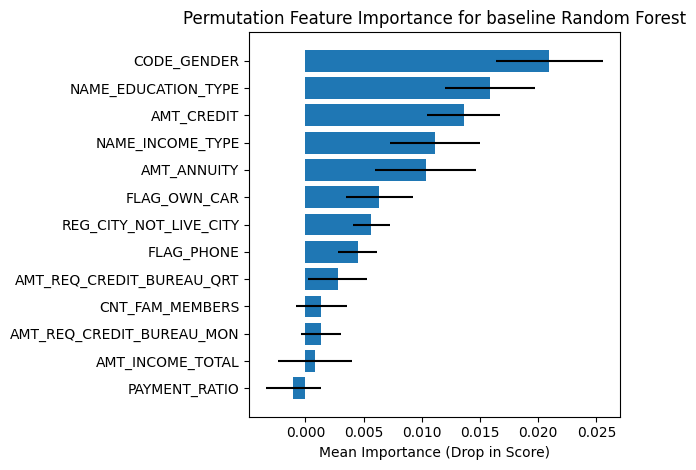

In [72]:
plt.barh(importance_df_rfc["feature"], importance_df_rfc["mean_importance"], xerr=importance_df_rfc["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance for baseline Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [73]:
# feature importance for baseline xgboost
result_xgb = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_xgb = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_xgb.importances_mean,\
    'std_importance': result_xgb.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importnace for baseline XGBOOST Algorithm")
importance_df_xgb

Feature importnace for baseline XGBOOST Algorithm


,feature,mean_importance,std_importance
3,AMT_CREDIT,0.043202,0.004088
4,AMT_ANNUITY,0.026855,0.002735
6,NAME_EDUCATION_TYPE,0.012739,0.001679
0,CODE_GENDER,0.009752,0.002489
12,PAYMENT_RATIO,0.007972,0.002929
5,NAME_INCOME_TYPE,0.007486,0.003419
1,FLAG_OWN_CAR,0.006596,0.002359
8,CNT_FAM_MEMBERS,0.003105,0.002780
9,REG_CITY_NOT_LIVE_CITY,0.002870,0.002320
11,AMT_REQ_CREDIT_BUREAU_QRT,0.002753,0.001907


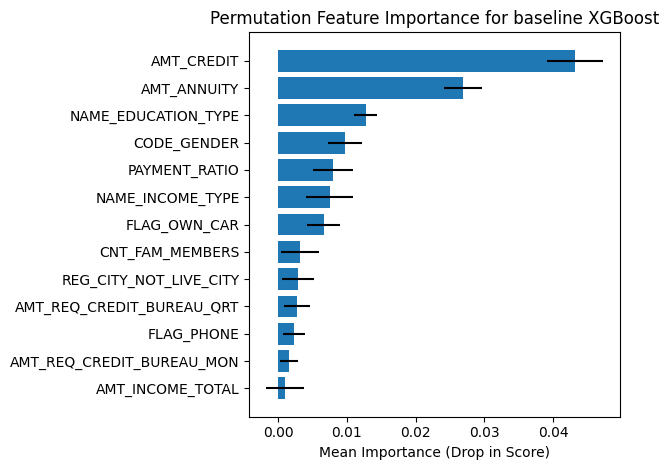

In [74]:
plt.barh(importance_df_xgb["feature"], importance_df_xgb["mean_importance"], xerr=importance_df_xgb["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance for baseline XGBoost")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [75]:
# feature importance for Random Forest Algorithm using Standardize data
result_rfc_std = permutation_importance(rfc_std, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_rfc_std = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_rfc_std.importances_mean,\
    'std_importance': result_rfc_std.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importance for Random Forest Algorithm using Standardize data")
importance_df_rfc_std

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature

Feature importance for Random Forest Algorithm using Standardize data


C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,feature,mean_importance,std_importance
6,NAME_EDUCATION_TYPE,0.002602,0.001370
1,FLAG_OWN_CAR,0.001511,0.001631
5,NAME_INCOME_TYPE,0.000671,0.001322
0,CODE_GENDER,0.000000,0.000000
2,AMT_INCOME_TOTAL,0.000000,0.000000
3,AMT_CREDIT,0.000000,0.000000
4,AMT_ANNUITY,0.000000,0.000000
9,REG_CITY_NOT_LIVE_CITY,0.000000,0.000000
12,PAYMENT_RATIO,-0.000050,0.001101
10,AMT_REQ_CREDIT_BUREAU_MON,-0.001108,0.001603


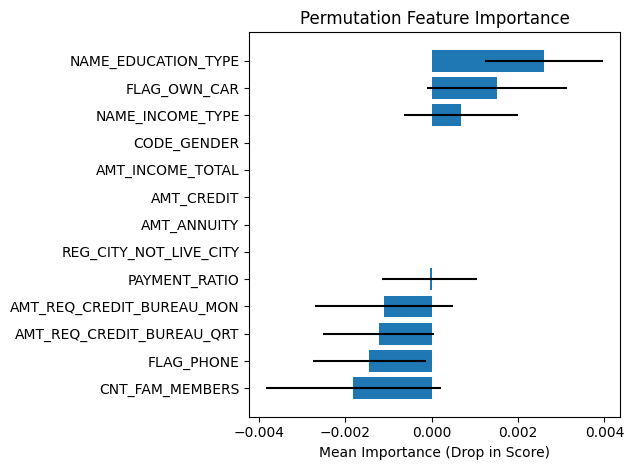

In [76]:
plt.barh(importance_df_rfc_std["feature"], importance_df_rfc_std["mean_importance"], xerr=importance_df_rfc_std["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [77]:
# feature importance for Random Forest Algorithm using Standardize data
result_xgb_std = permutation_importance(xgb_std, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_xgb_std = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_xgb_std.importances_mean,\
    'std_importance': result_xgb_std.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importance for Random Forest Algorithm using Standardize data")
importance_df_xgb_std

Feature importance for Random Forest Algorithm using Standardize data


,feature,mean_importance,std_importance
5,NAME_INCOME_TYPE,0.007184,0.002787
0,CODE_GENDER,0.004314,0.002041
8,CNT_FAM_MEMBERS,0.002585,0.001263
10,AMT_REQ_CREDIT_BUREAU_MON,0.001091,0.001681
6,NAME_EDUCATION_TYPE,0.000504,0.000676
1,FLAG_OWN_CAR,0.000000,0.000000
2,AMT_INCOME_TOTAL,0.000000,0.000000
3,AMT_CREDIT,0.000000,0.000000
4,AMT_ANNUITY,0.000000,0.000000
7,FLAG_PHONE,0.000000,0.000000


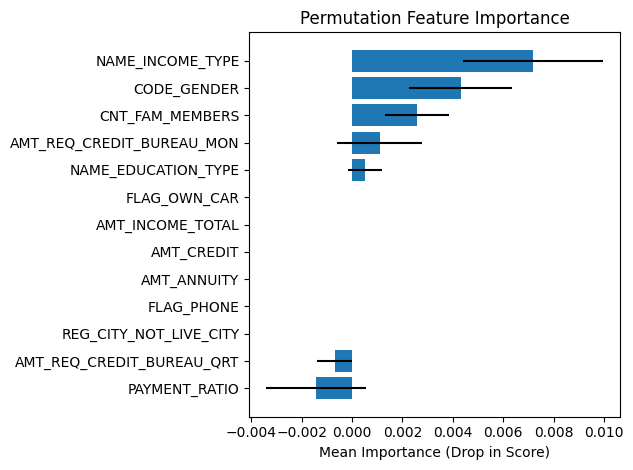

In [78]:
plt.barh(importance_df_xgb_std["feature"], importance_df_xgb_std["mean_importance"], xerr=importance_df_xgb_std["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Recommendation & Communication

#### Suggest business actionables based on model insights.

##### Insight 1: Payment Ratio is a strong predictor. A minimum threshold must be set.

##### Insight 2: Key Drivers of Risk(credit amount, annuity, type of income, type of education). Re-calibrate credit scoring policy to weigh top risk features more heavily. Automate red-flag detection during onboarding.

##### Insight 3: Ensure credit approval criteria for segments with high default probability. Introduce tiered interest rate. Implement pre-approval counseling.

In [79]:
###

#### Executive Summary: Asset Financing Risk Prediction Initiative
##### A machine learning-based asset financing risk prediction model is built based on the growing need for proactive credit risk management. 
##### This model(xgboost) aim at identifying high risk customers at risk of default. This models leverage features such as: debt-to-income ratio, annuity, credit amount, income amount, etc.

#### Key Insights:

##### a) The model(xgboost) can identify high-risk segments based on features like credit amount, annuity, type of income, and payment ratio.

##### b) Behavioral and demographic features such as type of education, gender, etc significantly influence default probability.

##### c) Model overall performance highlighted the need for more significant features.

#### Business Implications & Actions:

##### a) For high-risk customers, optimization of return is recommended for risk-based pricing and tiered loan.

##### b) Operational teams can adopt the model outputs to priotize loan approvals, refine recovery strategies, and reduce portfolio-level default rates. 

##### c) The insights support the initialization of early warning systems, personalized credit offerings, and targeted customer engagement for repayment.

##### d) This initiative indicates a critical step toward data-driven lending, enabling smarter decisions, reduced credit losses, and enhanced financial inclusion.

#### Limitations

##### This project is still under development and will require identifying and introducing new features such as loan term, gross monthly income, etc; which are not available now.

##### Also, more experiments can be designed to improve the performance. To mention but a few:

##### 1) Change encoding type from label to one-hot encoding.
##### 2) Utilize lightgbm algorithm and compare with others.
##### 3) Introduce relevant features not capture in the data, which can be important for feature engineering.
##### 4) Engage hyper-parameter tuning after taking all the steps above.
